<a href="https://colab.research.google.com/github/Janmeshree/DAV-PRACS/blob/main/DAV_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [4]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

data = pd.read_csv(url)

data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

data.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


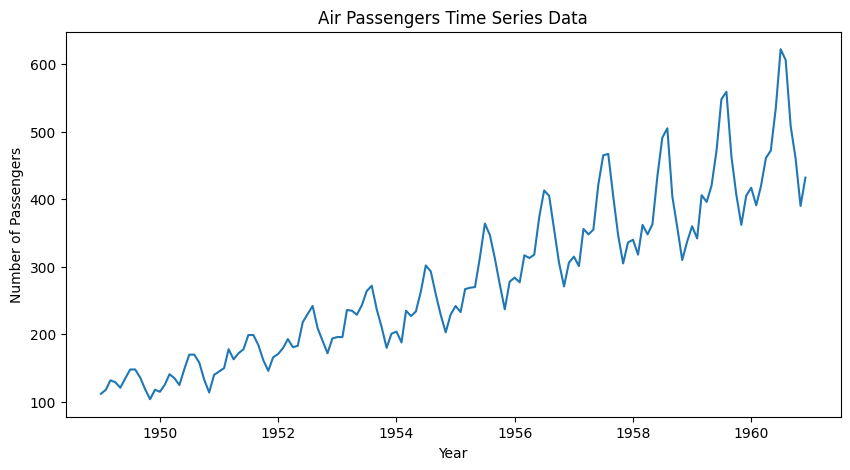

In [5]:
plt.figure(figsize=(10,5))
plt.plot(data['Passengers'])

plt.title("Air Passengers Time Series Data")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")

plt.show()

In [6]:
result = adfuller(data['Passengers'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] <= 0.05:
    print("Data is Stationary")
else:
    print("Data is Non-Stationary")

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
Data is Non-Stationary


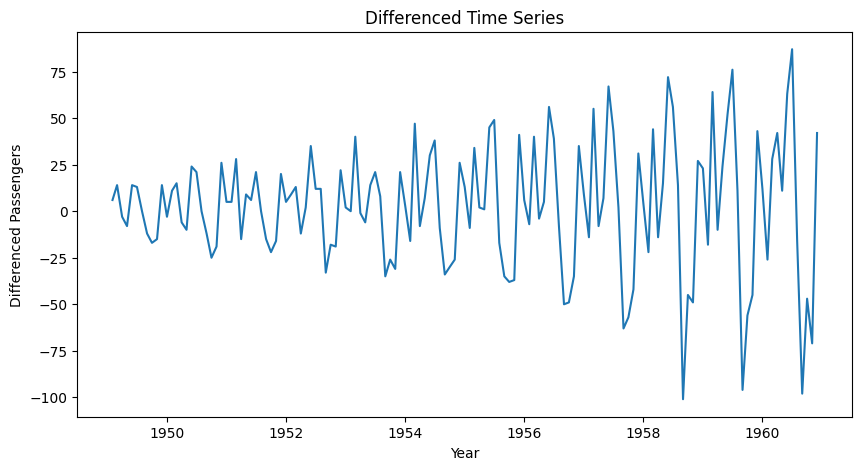

In [7]:
data_diff = data['Passengers'].diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(data_diff)

plt.title("Differenced Time Series")
plt.xlabel("Year")
plt.ylabel("Differenced Passengers")

plt.show()

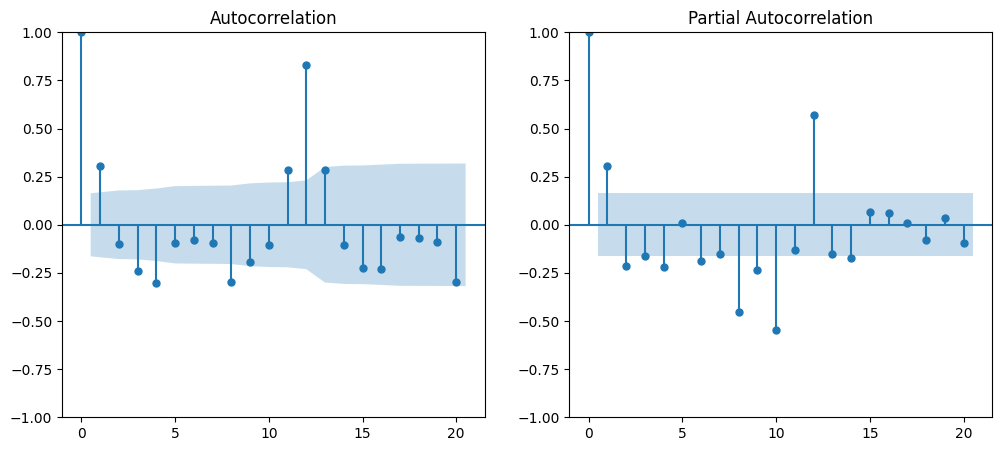

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(data_diff, ax=plt.gca(), lags=20)

plt.subplot(1,2,2)
plot_pacf(data_diff, ax=plt.gca(), lags=20)

plt.show()

In [9]:
model = ARIMA(data['Passengers'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -694.341
Date:                Sun, 19 Apr 2026   AIC                           1394.683
Time:                        18:18:50   BIC                           1403.571
Sample:                    01-01-1949   HQIC                          1398.294
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4742      0.123     -3.847      0.000      -0.716      -0.233
ma.L1          0.8635      0.078     11.051      0.000       0.710       1.017
sigma2       961.9270    107.433      8.954      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [10]:
forecast = model_fit.forecast(steps=10)

print("Forecasted Values:")
print(forecast)

Forecasted Values:
1961-01-01    475.735059
1961-02-01    454.996073
1961-03-01    464.830415
1961-04-01    460.167010
1961-05-01    462.378378
1961-06-01    461.329756
1961-07-01    461.827008
1961-08-01    461.591213
1961-09-01    461.703026
1961-10-01    461.650005
Freq: MS, Name: predicted_mean, dtype: float64


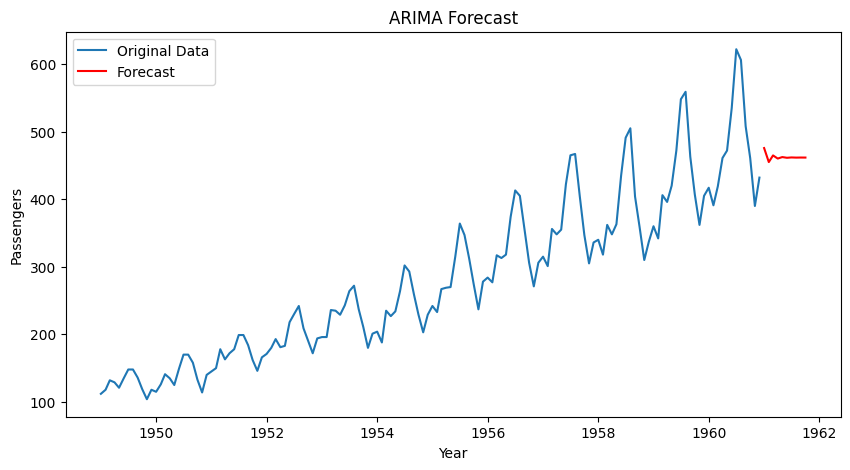

In [11]:
plt.figure(figsize=(10,5))

plt.plot(data['Passengers'], label="Original Data")
plt.plot(forecast.index, forecast, label="Forecast", color='red')

plt.title("ARIMA Forecast")
plt.xlabel("Year")
plt.ylabel("Passengers")

plt.legend()
plt.show()